# Importing Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Loading our dataset

In [2]:
try:
    df = pd.read_csv("houses_improved_data.csv")
    print("Dataset loaded successfully!")
except:
    print("Failed to load Dataset!")

Dataset loaded successfully!


# Display basic info

In [3]:
df.shape

(1000, 12)

In [4]:
df.head()

,Number_of_Rooms,Site_Area_sqm,Built_Area_sqm,Property_Years,Construction_Materials,Housing_Typology,Land_Value_Grading,Proximity_to_CBD_km,Proximity_to_Bus_Station_km,Type_of_Nearest_Road,Proximity_to_Schools_km,Price_ETB
0,3,402,275,18,Concrete,Semi-detached,Low,0.66,0.39,Gravel,1.51,2453165
1,6,111,72,5,Concrete,Semi-detached,High,0.12,1.38,Asphalt,2.04,2006785
2,4,417,306,2,Concrete,Condominium,Medium,5.00,2.21,Gravel,2.71,2164504
3,4,179,72,4,Mud&Wood,Condominium,Low,4.03,1.08,Asphalt,1.30,400087
4,3,315,147,12,Concrete,Semi-detached,Medium,3.95,1.26,Asphalt,2.89,1366641


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Rooms              1000 non-null   int64  
 1   Site_Area_sqm                1000 non-null   int64  
 2   Built_Area_sqm               1000 non-null   int64  
 3   Property_Years               1000 non-null   int64  
 4   Construction_Materials       1000 non-null   str    
 5   Housing_Typology             1000 non-null   str    
 6   Land_Value_Grading           1000 non-null   str    
 7   Proximity_to_CBD_km          1000 non-null   float64
 8   Proximity_to_Bus_Station_km  1000 non-null   float64
 9   Type_of_Nearest_Road         1000 non-null   str    
 10  Proximity_to_Schools_km      1000 non-null   float64
 11  Price_ETB                    1000 non-null   int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 93.9 KB


In [6]:
df.describe(include=['object', 'str'])

,Construction_Materials,Housing_Typology,Land_Value_Grading,Type_of_Nearest_Road
count,1000,1000,1000,1000
unique,2,3,3,2
top,Concrete,Detached,Medium,Asphalt
freq,651,411,503,639


In [7]:
df.describe()

,Number_of_Rooms,Site_Area_sqm,Built_Area_sqm,Property_Years,Proximity_to_CBD_km,Proximity_to_Bus_Station_km,Proximity_to_Schools_km,Price_ETB
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,3.716000,356.639000,204.622000,12.61800,2.510380,1.265490,1.586820,2.111505e+06
std,1.001172,147.084808,93.434861,7.56527,1.421643,0.681525,0.799072,1.375801e+06
min,2.000000,100.000000,44.000000,0.00000,0.100000,0.100000,0.200000,4.000000e+05
25%,3.000000,230.750000,128.750000,6.00000,1.280000,0.687500,0.910000,1.087284e+06
50%,4.000000,365.500000,202.000000,13.00000,2.480000,1.260000,1.590000,1.789488e+06
75%,4.000000,481.000000,269.000000,19.00000,3.802500,1.822500,2.260000,2.822250e+06
max,6.000000,599.000000,438.000000,25.00000,5.000000,2.500000,3.000000,9.779324e+06


# EDA

## Histogram | Box plot | Log transform histogram

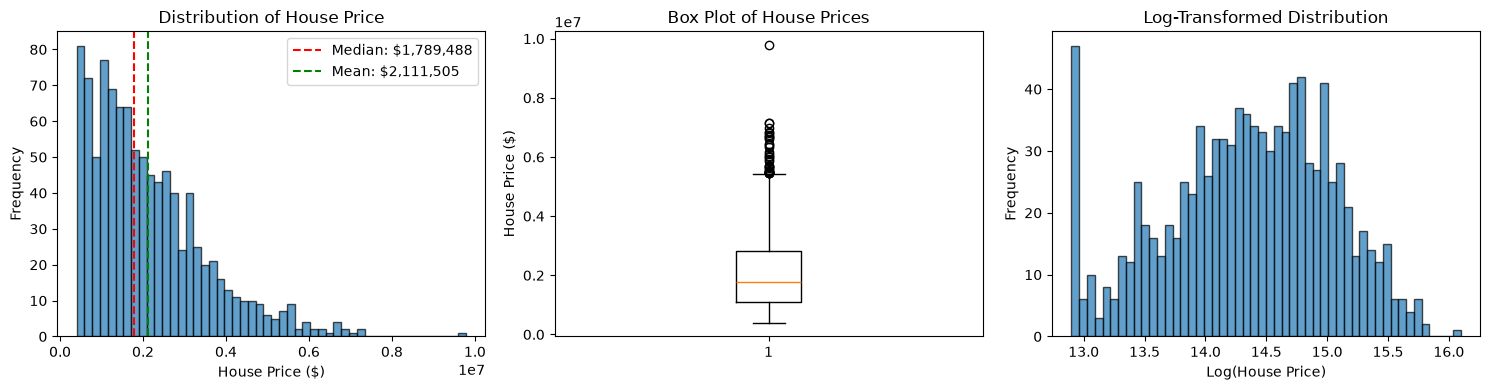

In [8]:
# Distribution of target variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Histogram
axes[0].hist(df['Price_ETB'], bins=50, edgecolor='black',
alpha=0.7)
axes[0].set_xlabel('House Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of House Price')
axes[0].axvline(df['Price_ETB'].median(), color='red',
linestyle='--',
label=f'Median: ${df["Price_ETB"].median():,.0f}')
axes[0].axvline(df['Price_ETB'].mean(), color='green',
linestyle='--',
label=f'Mean: ${df["Price_ETB"].mean():,.0f}')
axes[0].legend()
# Box plot
axes[1].boxplot(df['Price_ETB'])
axes[1].set_ylabel('House Price ($)')
axes[1].set_title('Box Plot of House Prices')
# Log transform
axes[2].hist(np.log1p(df['Price_ETB']), bins=50,
edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Log(House Price)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Log-Transformed Distribution')
plt.tight_layout()
plt.show()


# Encoding

In [24]:
df.describe(include=['object', 'str'])

,Construction_Materials,Housing_Typology,Land_Value_Grading,Type_of_Nearest_Road
count,1000,1000,1000,1000
unique,2,3,3,2
top,Concrete,Detached,Medium,Asphalt
freq,651,411,503,639


In [25]:
le = LabelEncoder()
df['Construction_Materials_encoded'] = le.fit_transform(df['Construction_Materials'])
df['Housing_Typology_encoded'] = le.fit_transform(df['Housing_Typology'])
df['Type_of_Nearest_Road_encoded'] = le.fit_transform(df['Type_of_Nearest_Road'])

# encoding land value with a map
grading_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Land_Value_Grading_encoded'] = df['Land_Value_Grading'].map(grading_map)


In [26]:
df.head()

,Number_of_Rooms,Site_Area_sqm,Built_Area_sqm,Property_Years,Construction_Materials,Housing_Typology,Land_Value_Grading,Proximity_to_CBD_km,Proximity_to_Bus_Station_km,Type_of_Nearest_Road,Proximity_to_Schools_km,Price_ETB,Construction_Materials_encoded,Housing_Typology_encoded,Land_Value_Grading_encoded,Type_of_Nearest_Road_encoded
0,3,402,275,18,Concrete,Semi-detached,Low,0.66,0.39,Gravel,1.51,2453165,0,2,0,1
1,6,111,72,5,Concrete,Semi-detached,High,0.12,1.38,Asphalt,2.04,2006785,0,2,2,0
2,4,417,306,2,Concrete,Condominium,Medium,5.00,2.21,Gravel,2.71,2164504,0,0,1,1
3,4,179,72,4,Mud&Wood,Condominium,Low,4.03,1.08,Asphalt,1.30,400087,1,0,0,0
4,3,315,147,12,Concrete,Semi-detached,Medium,3.95,1.26,Asphalt,2.89,1366641,0,2,1,0


# Correlation with target variable

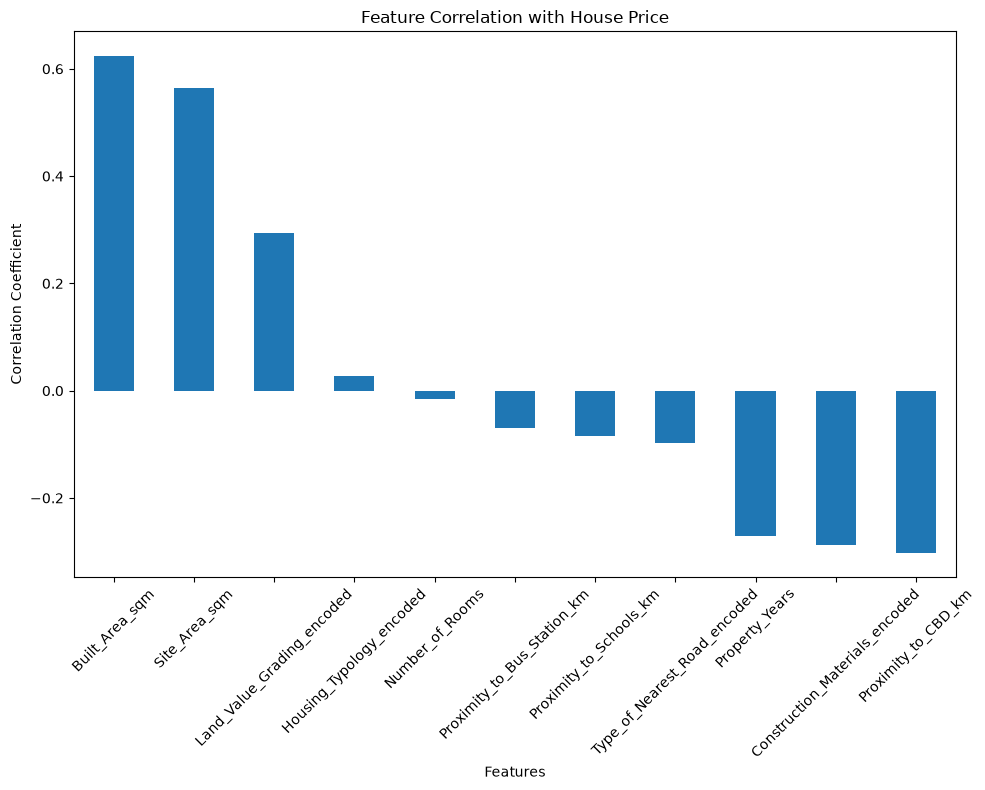

Top correlations with Price_ETB:
Price_ETB                       1.000000
Built_Area_sqm                  0.623637
Site_Area_sqm                   0.563448
Land_Value_Grading_encoded      0.294603
Housing_Typology_encoded        0.027131
Number_of_Rooms                -0.014894
Proximity_to_Bus_Station_km    -0.069370
Proximity_to_Schools_km        -0.084817
Type_of_Nearest_Road_encoded   -0.097387
Property_Years                 -0.270473
Name: Price_ETB, dtype: float64


In [27]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['Price_ETB'].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
correlations.drop('Price_ETB').plot(kind='bar')
plt.title('Feature Correlation with House Price')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Top correlations with Price_ETB:")
print(correlations.head(10))

## Scatter plots for important features

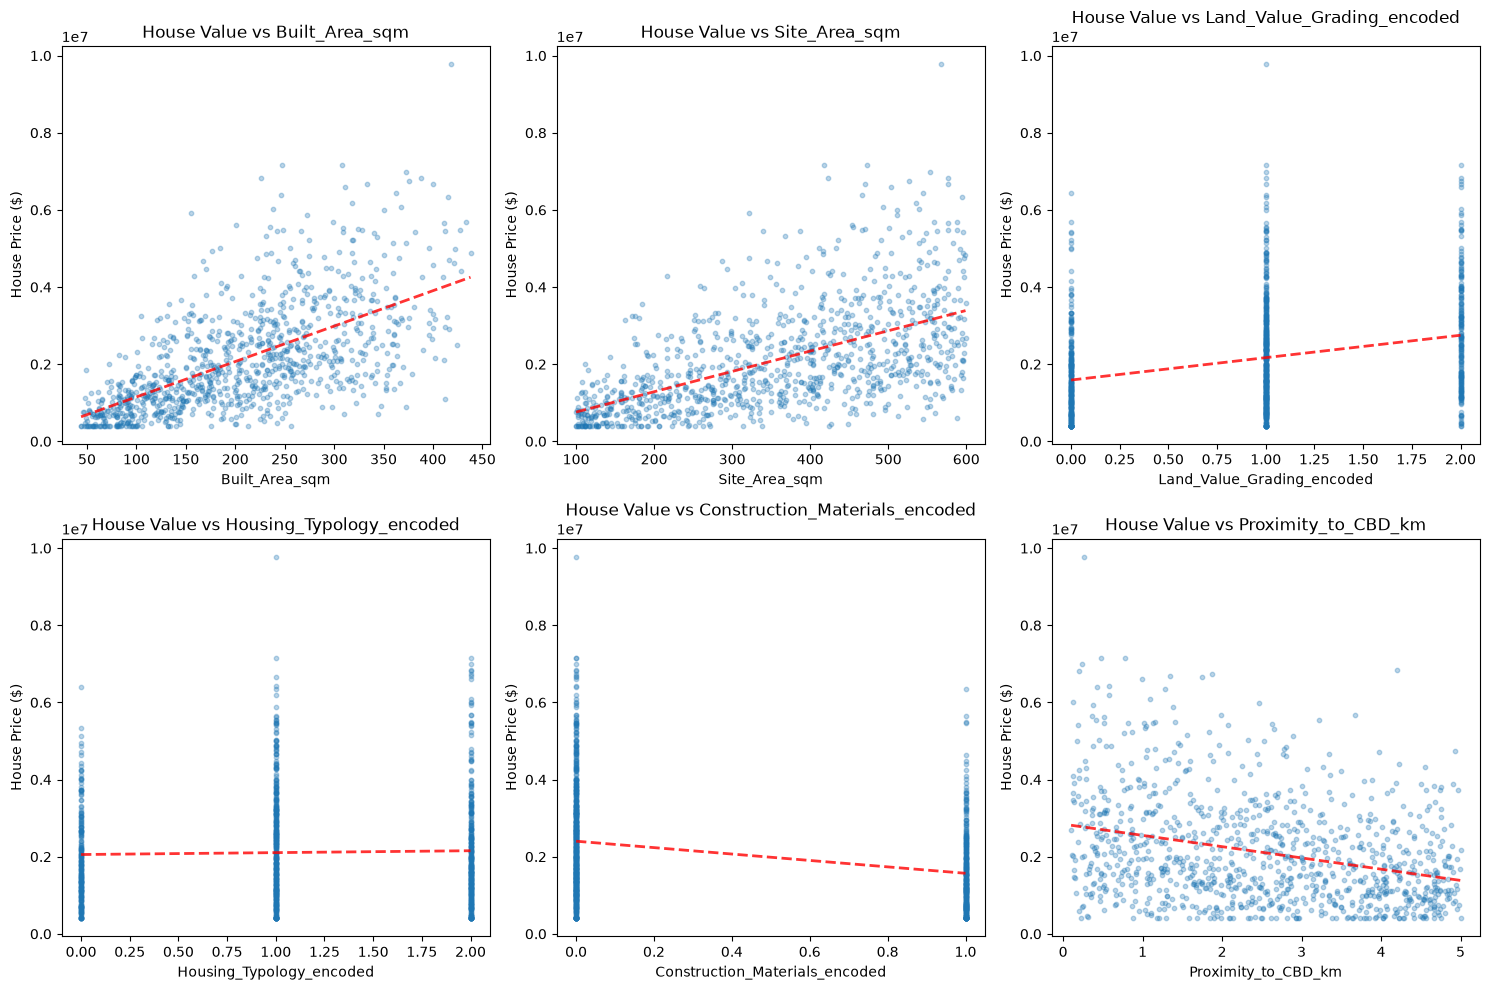

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = [
    'Built_Area_sqm', 
    'Site_Area_sqm', 
    'Land_Value_Grading_encoded', 
    'Housing_Typology_encoded', 
    'Construction_Materials_encoded', 
    'Proximity_to_CBD_km', 
]
for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].scatter(df[feature], df['Price_ETB'],
    alpha=0.3, s=10)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('House Price ($)')
    axes[row, col].set_title(f'House Value vs {feature}')
    # Add trend line
    z = np.polyfit(df[feature], df['Price_ETB'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(df[feature].sort_values(),
    p(df[feature].sort_values()),
    "r--", alpha=0.8, linewidth=2)
plt.tight_layout()
plt.show()

# Selecting Features

In [30]:
feature_cols = [
    'Number_of_Rooms', 
    'Site_Area_sqm', 
    'Built_Area_sqm', 
    'Property_Years', 
    'Proximity_to_CBD_km', 
    'Proximity_to_Schools_km', 
    'Construction_Materials_encoded', 
    'Housing_Typology_encoded', 
    'Land_Value_Grading_encoded',
    'Type_of_Nearest_Road_encoded'
]
X_multivariate = df[feature_cols]
y = df['Price_ETB']
print(f"Selected features: {feature_cols}")
print(f"\nFeature matrix shape: {X_multivariate.shape}")

Selected features: ['Number_of_Rooms', 'Site_Area_sqm', 'Built_Area_sqm', 'Property_Years', 'Proximity_to_CBD_km', 'Proximity_to_Schools_km', 'Construction_Materials_encoded', 'Housing_Typology_encoded', 'Land_Value_Grading_encoded', 'Type_of_Nearest_Road_encoded']

Feature matrix shape: (1000, 10)


# Split data and train

In [31]:
X_train_multi, X_test_multi, y_train, y_test = train_test_split(
    X_multivariate, y, test_size=0.2, random_state=42
)
# Feature scaling (important for multivariate regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)
# Train multivariate model
multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -11722.76, 36629.22, 903952.43,..., 75292.03, 476836.45,-181204.65]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.102e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[39.34,30.48,29.47,...,26.77,26.51, 8.57]"


# Display coefficients

In [32]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': multi_model.coef_,
    'Abs_Coefficient': np.abs(multi_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)
print("Multivariate Linear Regression Model:")
print(f"Intercept: ${multi_model.intercept_:,.2f}")
115
print("\nFeature Coefficients (scaled - shows relative importance):")
print(coef_df.to_string(index=False))

Multivariate Linear Regression Model:
Intercept: $2,102,110.65

Feature Coefficients (scaled - shows relative importance):
                       Feature    Coefficient  Abs_Coefficient
                Built_Area_sqm  903952.425319    903952.425319
    Land_Value_Grading_encoded  476836.448247    476836.448247
                Property_Years -467213.040219    467213.040219
           Proximity_to_CBD_km -442650.180454    442650.180454
Construction_Materials_encoded -427574.175684    427574.175684
  Type_of_Nearest_Road_encoded -181204.653628    181204.653628
       Proximity_to_Schools_km -138400.267760    138400.267760
      Housing_Typology_encoded   75292.032218     75292.032218
                 Site_Area_sqm   36629.216506     36629.216506
               Number_of_Rooms  -11722.759056     11722.759056


# Make predictions

In [17]:
y_pred_multi_train = multi_model.predict(X_train_scaled)
y_pred_multi_test = multi_model.predict(X_test_scaled)
# Evaluate
train_rmse_multi = np.sqrt(mean_squared_error(y_train, y_pred_multi_train))
test_rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi_test))
train_r2_multi = r2_score(y_train, y_pred_multi_train)
test_r2_multi = r2_score(y_test, y_pred_multi_test)
print("Multivariate Model Performance:")
print(f"Training RMSE: ${train_rmse_multi:,.2f}")
print(f"Test RMSE: ${test_rmse_multi:,.2f}")
print(f"Training R² Score: {train_r2_multi:.4f}")
print(f"Test R² Score: {test_r2_multi:.4f}")

Multivariate Model Performance:
Training RMSE: $745,569.23
Test RMSE: $723,994.13
Training R² Score: 0.7148
Test R² Score: 0.6836


# Function to predict house value

In [35]:
def predict_my_house_value(
    number_of_rooms, 
    site_area_sqm, 
    built_area_sqm, 
    property_years, 
    proximity_to_cbd_km, 
    proximity_to_schools_km, 
    construction_materials_encoded, 
    housing_typology_encoded, 
    land_grade,               
    type_of_nearest_road_encoded
):
    
    # mappint raw text to its custom numeric value
    grading_map = {'Low': 0, 'Medium': 1, 'High': 2}
    land_value_grading_encoded = grading_map.get(land_grade, 1) # defaults to 'Medium' if not given
    
    # column names listed exactly as they were trained
    feature_names = [
        'Number_of_Rooms', 'Site_Area_sqm', 'Built_Area_sqm', 'Property_Years', 
        'Proximity_to_CBD_km', 'Proximity_to_Schools_km', 'Construction_Materials_encoded', 
        'Housing_Typology_encoded', 'Land_Value_Grading_encoded', 'Type_of_Nearest_Road_encoded'
    ]
    
    # create a DataFrame
    raw_inputs_df = pd.DataFrame([[
        number_of_rooms, 
        site_area_sqm, 
        built_area_sqm, 
        property_years, 
        proximity_to_cbd_km, 
        proximity_to_schools_km, 
        construction_materials_encoded, 
        housing_typology_encoded, 
        land_value_grading_encoded,       
        type_of_nearest_road_encoded
    ]], columns=feature_names)
    
    # scale and predict using the DataFrame
    scaled_inputs = scaler.transform(raw_inputs_df)
    predicted_price = multi_model.predict(scaled_inputs)
    
    return predicted_price


In [39]:
test_prediction = predict_my_house_value(
    number_of_rooms=3, 
    site_area_sqm=250.0, 
    built_area_sqm=120.0, 
    property_years=5, 
    proximity_to_cbd_km=2.5, 
    proximity_to_schools_km=0.8, 
    construction_materials_encoded=1, 
    housing_typology_encoded=0, 
    land_grade='High',
    type_of_nearest_road_encoded=1
)


print(f"Calculated Property Prediction: ETB {test_prediction[0]:,.2f}")

Calculated Property Prediction: ETB 1,701,219.68


# Export Model

In [43]:
joblib.dump(multi_model, 'property_model.pkl')
joblib.dump(scaler, 'property_scaler.pkl')
print("Model and Scaler successfully saved!")

Model and Scaler successfully saved!
